In [27]:
import numpy as np
import matplotlib.pyplot as plt 
from sympy import Symbol, Eq,exp, sqrt, lambdify
from sympy import exp, sqrt, Max
from scipy.optimize import fsolve
import xarray as xr
from netCDF4 import Dataset

In [ ]:
epsilon = 0.622 
A_1 = 8e-4  # (kg/(m·s²·K^3.5))
A = 2.5e6  # (J/kg)
B = 2.38e3  # (J/(kg K))
cp = 1001
R =  287  # (J/(kg·K))
g = 9.81

es0    = 611
beta   = 0.067
tmelt = 273.16
es0    = 611
beta   = 0.067
eps0   = 0.622

rlv    = 2.5e6

In [ ]:
def w(T,P):
    #mixing ratio
    return epsilon*A_1*(T - 223.15)**3.5/P

def L(T):
    #latent heat of condensation
    return A - B*(T - 273.15)

def e_s(T):
    #saturation vapor pressure
    T_C = T - 273.15
    return 6.112 * np.exp((17.67 * T_C) / (T_C + 243.5))

def qsat(p,t):
    es = es0*np.exp(beta*(t-tmelt))
    qsat = eps0*es/p
    return qsat

def cond (tl,qt,p,ql):
    ql     = (qt-qsat(p,tl))/(1+(rlv/cp)*beta*qsat(p,tl))
    #ql     = np.clip(ql,0,0.01)
    ql     = np.clip(ql,0,10)
    return ql

In [ ]:
T_surf = 289.38
p_surf = 101325
T_d = 286.52

In [ ]:
p_air = np.linspace(p_surf, 100, 1000)
T_air = T_surf*(p_air/p_surf)**0.286
p_s = (1/((T_surf - T_d)/223.15 + 1))**3.5 * p_surf
T_s = (1/((T_surf - T_d)/223.15 + 1))* T_surf

theta_moist_parcel = T_s*(p_s/p_surf)**0.286*np.exp(L(T_s)*w(T_s,p_s)/(cp*T_s))
lcl_index = (np. abs(p_air - p_s)). argmin()
T_arr = T_air*np.ones(len(T_air))
for i in range(lcl_index,len(p_air)):
    print(i)
    T_parcel = Symbol('T_parcel')
    T_func = Eq(theta_moist_parcel,T_parcel * (p_surf / p_air[i])**0.286 * exp((A - B * (T_parcel - 273.15)) * (epsilon*A_1*abs(T_parcel - 223.15)**3.5/(p_air[i])) / (cp * T_parcel)))
    T_solve = lambdify(T_parcel, T_func.lhs - T_func.rhs, 'numpy')
    T_parcel = fsolve(T_solve, T_air[i])
    T_arr[i] = T_parcel





In [ ]:
Z = np.linspace(0,25000,1000)
T_env = T_surf - Z*0.0065

p_z = (1- (Z*0.0065/T_air))**(1/(R*0.0065/g))*p_surf

In [ ]:
p_z

In [ ]:
Z = R*(T_surf + T_parcel)/(2*g)*np.log(p_surf/p_air)
Z_sat = R*(T_surf + T_arr[lcl_index])/(2*g)*np.log(p_surf/p_air[lcl_index])
print(Z)

In [ ]:
q_t = w(T_surf,p_surf)
q_v = np.zeros(len(T_arr))
q_l = np.zeros(len(T_arr))
q_v[0:lcl_index] = q_t*np.ones((lcl_index))
q_v[lcl_index:] = w(T_arr[lcl_index:],p_air[lcl_index:])
q_l[0:lcl_index] = 0
q_l[lcl_index:] = q_t - q_v[lcl_index:]


In [ ]:
plt.plot(q_v,Z)
plt.plot(q_l,Z)

In [ ]:
dz = np.diff(Z)
dz

In [ ]:
#with entraintment
entr = 1e-3
q_t_p = np.zeros(len(T_arr))
q_t_p[0:lcl_index+1] = q_v[0:lcl_index+1]
dz = np.diff(Z)
theta_l_p = np.zeros(len(T_arr))
theta_l_p[0:lcl_index+1] = T_surf
theta_l = T_air + g/cp*Z
for i in range(lcl_index,len(T_arr)-1):
    q_t_p[i+1] = q_t_p[i] - entr*(q_t_p[i])*dz[i]
    theta_l_p[i+1] = theta_l_p[i] - entr*(theta_l_p[i] - theta_l[i])

tlp_1 = theta_l_p - g/cp * Z
qlp_1 = cond(tlp_1, q_t_p, p_air, ql)
Tp_1= tlp_1 + rlv/cp*qlp_1
qvp_1 = qtp_1 - qlp_1
Tvp_1 = Tp_1*(1  + 0.608*qvp_1 - qlp_1)


In [ ]:
lbb_index = (np. abs(p_z - 20000)). argmin()

In [ ]:
p_z.min()

In [ ]:
diff = np.mean(T_v_moist[lcl_index:500] - T_air[lcl_index:500])

In [ ]:
diff

In [ ]:

T_v_moist = T_arr*(1 +0.61*q_v - q_l)
T_v_e  = T_env*(1 +0.61*q_t)
lfc_index = (np. abs(T_v_moist[:-400] - T_air[:-400])). argmin()
plt.figure(figsize=(10,6))
plt.plot(T_v_moist,p_z,linewidth=0.7,label='T_moist_parcel')
plt.plot(T_v_e,p_z,linewidth=0.7,label='T_v_env')
plt.plot(T_air,p_z,linewidth=0.7,label='T_v_dry')
plt.gca().invert_yaxis()
plt.axhline(y=p_s, color='r', linestyle='--',linewidth='0.4',label='LCL')
plt.axhline(y=p_z[lfc_index], color='grey', linestyle='--',linewidth='0.6',label='LNB')
#plt.axvline(x=T_s, color='r', linestyle='--',linewidth='0.4')
plt.xlabel('Virtual Temperature [K]')
plt.ylabel('Pressure [Pa]')
plt.legend()
plt.grid()

In [ ]:
T_v_moist.dropna()

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(T_air,p_air/100,linewidth=0.7,label='T_dry_parcel')
plt.plot(T_arr,p_air/100,linewidth=0.7,label='T_moist_parcel')
plt.plot(T_env,p_z/100,linewidth=0.7,label='T_env')
plt.gca().invert_yaxis()
plt.axhline(y=p_s/100, color='r', linestyle='--',linewidth='0.4',label='LCL')
#plt.axvline(x=T_s, color='r', linestyle='--',linewidth='0.4',label='LCL')
plt.xlabel('Temperature [K]')
plt.ylabel('Pressure level [hPa]')
plt.legend()
plt.grid()

In [ ]:
modis = xr.open_mfdataset(r"C:\Users\chari\Downloads\MCD06COSP_D3_MODIS.A2024187.062.2024195000753.nc")

In [28]:
ds = Dataset(r"C:\Users\chari\Downloads\MCD06COSP_D3_MODIS.A2024187.062.2024195000753.nc")
print(ds.variables.keys())

dict_keys(['latitude', 'longitude'])


In [30]:
ctp_group = ds.groups['Cloud_Top_Pressure']
ctp_data = ctp_group.variables['Mean'][:]

In [31]:
ctp_mean = ctp_group.variables['Mean'][:]  # shape: [longitude, latitude]

In [32]:
ctp_mean = np.ma.masked_where(ctp_mean == -999.0, ctp_mean)
ctp_mean

masked_array(
  data=[[--, --, --, ..., 900.0367647058823, 759.5588235294117,
         766.4285714285714],
        [--, --, --, ..., 890.3592814371258, 664.6610169491526,
         670.2631578947369],
        [--, --, --, ..., 871.4238410596026, 781.0, 744.6666666666666],
        ...,
        [--, --, --, ..., 880.1923076923077, 720.6034482758621,
         723.9130434782609],
        [--, --, --, ..., 885.8561643835617, 730.0, 654.6428571428571],
        [--, --, --, ..., 867.2413793103449, 781.484375,
         803.9473684210526]],
  mask=[[ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        ...,
        [ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False],
        [ True,  True,  True, ..., False, False, False]],
  fill_value=-999.0)

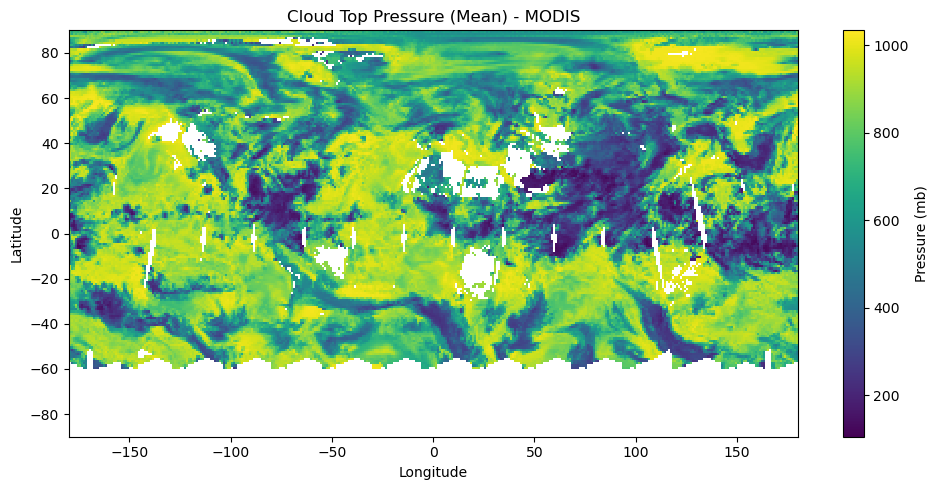

In [33]:
lon = ds.variables['longitude'][:]
lat = ds.variables['latitude'][:]
plt.figure(figsize=(10, 5))
plt.pcolormesh(lon, lat, ctp_mean.T, shading='auto', cmap='viridis')
plt.title("Cloud Top Pressure (Mean) - MODIS")
plt.colorbar(label='Pressure (mb)')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

In [34]:
target_lat = 51.9653
target_lon = 4.8979

# Find nearest indices
lat_idx = (np.abs(lat - target_lat)).argmin()
lon_idx = (np.abs(lon - target_lon)).argmin()

# Get the corresponding value
ctp_value = ctp_mean[lon_idx, lat_idx]

In [35]:
ctp_value

487.1780303030303